# All Components Smoke Test

This is a visual walkthrough of the four local AGFB components. Each stage shows a standard notebook image output first, then the table for that stage.

Flow. `agfb-generators` -> `agfb-noise` -> `agfb-filters` -> `agfb-metrics`.

In [1]:
import os
from pathlib import Path
import sys

import numpy as np
from IPython.display import Markdown, display
from PIL import Image, ImageDraw, ImageFont

COMPONENT_DIRS = ("agfb-generators", "agfb-noise", "agfb-filters", "agfb-metrics")
BRAND = {
    "garnet": "#73000A",
    "black": "#000000",
    "white": "#FFFFFF",
    "black90": "#363636",
    "black50": "#A2A2A2",
    "black30": "#C7C7C7",
    "rose": "#CC2E40",
    "atlantic": "#466A9F",
    "congaree": "#1F414D",
}


def has_components(path: Path) -> bool:
    return all((path / name).is_dir() for name in COMPONENT_DIRS)


def find_workspace() -> Path:
    starts = [Path.cwd().resolve(), Path("/Users/user/Documents/New project/AGFB")]
    notebook_file = globals().get("__vsc_ipynb_file__")
    if notebook_file:
        starts.insert(0, Path(notebook_file).resolve().parent)
    for env_name in ("PWD", "JUPYTER_SERVER_ROOT"):
        if os.environ.get(env_name):
            starts.append(Path(os.environ[env_name]).resolve())
    seen = set()
    for start in starts:
        for candidate in (start, *start.parents):
            for option in (
                candidate,
                candidate / "AGFB",
                candidate / "Documents" / "New project" / "AGFB",
            ):
                if option in seen:
                    continue
                seen.add(option)
                if has_components(option):
                    return option
    raise RuntimeError("Could not find the AGFB workspace with all four component folders.")


def markdown_table(rows, columns=None):
    if not rows:
        display(Markdown("No rows."))
        return
    selected = columns or list(rows[0])
    lines = [
        "| " + " | ".join(selected) + " |",
        "| " + " | ".join("---" for _ in selected) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(str(row.get(column, "")) for column in selected) + " |")
    display(Markdown("\n".join(lines)))


def hex_to_rgb(color):
    color = color.lstrip("#")
    return np.array([int(color[i : i + 2], 16) for i in (0, 2, 4)], dtype=np.float32)


def mix_rgb(low, high, t):
    t = np.clip(np.asarray(t, dtype=np.float32), 0.0, 1.0)[..., None]
    low_rgb = hex_to_rgb(low)
    high_rgb = hex_to_rgb(high)
    return np.rint(low_rgb + (high_rgb - low_rgb) * t).astype(np.uint8)


def tensor_summary(name, tensor):
    data = tensor.detach().float().cpu()
    return {
        "tensor": name,
        "shape": tuple(tensor.shape),
        "dtype": str(tensor.dtype).replace("torch.", ""),
        "device": str(tensor.device),
        "min": f"{float(data.min()):.6f}",
        "max": f"{float(data.max()):.6f}",
        "mean": f"{float(data.mean()):.6f}",
        "std": f"{float(data.std(unbiased=False)):.6f}",
    }


def color_image(tensor, vmin=None, vmax=None, palette="sequential", high=BRAND["garnet"], size=128):
    import torch.nn.functional as F

    data = tensor.detach().float().cpu()
    data = F.interpolate(
        data.view(1, 1, data.shape[0], data.shape[1]),
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    ).squeeze()
    array = data.numpy()

    if palette == "signed":
        limit = max(abs(float(array.min())), abs(float(array.max())), 1e-12)
        scaled = np.clip(array / limit, -1.0, 1.0)
        rgb = np.empty((*scaled.shape, 3), dtype=np.uint8)
        negative = scaled < 0.0
        rgb[negative] = mix_rgb(BRAND["white"], BRAND["atlantic"], np.abs(scaled[negative]))
        rgb[~negative] = mix_rgb(BRAND["white"], BRAND["garnet"], scaled[~negative])
        return Image.fromarray(rgb, mode="RGB")

    lo = float(array.min()) if vmin is None else float(vmin)
    hi = float(array.max()) if vmax is None else float(vmax)
    scaled = np.clip((array - lo) / max(hi - lo, 1e-12), 0.0, 1.0)
    if palette == "gray":
        rgb = mix_rgb(BRAND["black"], BRAND["white"], scaled)
    else:
        rgb = mix_rgb(BRAND["white"], high, scaled)
    return Image.fromarray(rgb, mode="RGB")


def display_image_grid(title, panels, columns=3, cell_px=128):
    gap = 18
    pad = 12
    label_h = 30
    rows = (len(panels) + columns - 1) // columns
    width = columns * cell_px + (columns - 1) * gap + 2 * pad
    height = rows * (cell_px + label_h) + (rows - 1) * gap + 2 * pad
    canvas = Image.new("RGB", (width, height), BRAND["white"])
    draw = ImageDraw.Draw(canvas)
    font = ImageFont.load_default()
    label_fill = tuple(hex_to_rgb(BRAND["black90"]).astype(np.uint8).tolist())
    border_fill = tuple(hex_to_rgb(BRAND["black90"]).astype(np.uint8).tolist())

    for index, panel in enumerate(panels):
        row, column = divmod(index, columns)
        x = pad + column * (cell_px + gap)
        y = pad + row * (cell_px + label_h + gap)
        label = panel["title"]
        draw.text((x, y), label, fill=label_fill, font=font)
        image_y = y + label_h
        image = panel["image"].resize((cell_px, cell_px), Image.Resampling.BILINEAR)
        canvas.paste(image, (x, image_y))
        draw.rectangle((x, image_y, x + cell_px - 1, image_y + cell_px - 1), outline=border_fill)

    display(Markdown(f"**{title}**"))
    display(canvas)


WORKSPACE = find_workspace()
for component_dir in reversed(COMPONENT_DIRS):
    path = str(WORKSPACE / component_dir)
    if path not in sys.path:
        sys.path.insert(0, path)

markdown_table(
    [
        {"item": "workspace", "value": WORKSPACE},
        {"item": "component folders found", "value": len(COMPONENT_DIRS)},
        {"item": "image renderer", "value": "standard notebook PNG output with Pillow"},
        {"item": "first import path", "value": sys.path[0]},
    ]
)

| item | value |
| --- | --- |
| workspace | /Users/user/Documents/New project/AGFB |
| component folders found | 4 |
| image renderer | standard notebook PNG output with Pillow |
| first import path | /Users/user/Documents/New project/AGFB/agfb-noise |

In [2]:
import math
import torch
from agfb_filters import ExecutionPath, get_filter_definition, run_filter
from agfb_generators import smoothed_step
from agfb_metrics import evaluate_metrics, masks
from agfb_noise import add_gaussian
import agfb_filters
import agfb_generators
import agfb_metrics
import agfb_noise

torch.set_grad_enabled(False)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

markdown_table(
    [
        {"component": "agfb-generators", "import": agfb_generators.__file__},
        {"component": "agfb-noise", "import": agfb_noise.__file__},
        {"component": "agfb-filters", "import": agfb_filters.__file__},
        {"component": "agfb-metrics", "import": agfb_metrics.__file__},
        {"component": "torch", "import": f"{torch.__version__} on {DEVICE}"},
    ]
)

| component | import |
| --- | --- |
| agfb-generators | /Users/user/Documents/New project/AGFB/agfb-generators/agfb_generators/__init__.py |
| agfb-noise | /Users/user/Documents/New project/AGFB/agfb-noise/agfb_noise/__init__.py |
| agfb-filters | /Users/user/Documents/New project/AGFB/agfb-filters/agfb_filters/__init__.py |
| agfb-metrics | /Users/user/Documents/New project/AGFB/agfb-metrics/agfb_metrics/__init__.py |
| torch | 2.6.0 on cpu |

**Stage 1. Generated image first, then tensor table**

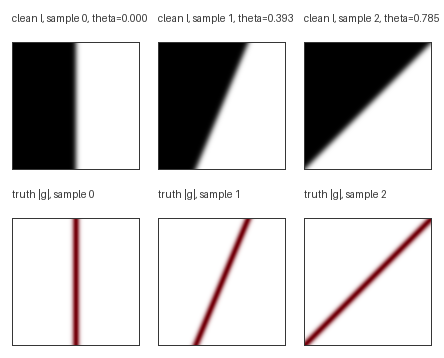

| sample | angle_rad |
| --- | --- |
| 0 | 0.000000 |
| 1 | 0.392699 |
| 2 | 0.785398 |

| tensor | shape | dtype | device | min | max | mean | std |
| --- | --- | --- | --- | --- | --- | --- | --- |
| clean intensity | (3, 128, 128) | float32 | cpu | 0.000000 | 1.000000 | 0.500000 | 0.487093 |
| truth gx | (3, 128, 128) | float32 | cpu | 0.000000 | 0.156417 | 0.007755 | 0.026642 |
| truth gy | (3, 128, 128) | float32 | cpu | 0.000000 | 0.112838 | 0.003626 | 0.015428 |
| truth magnitude | (3, 128, 128) | float32 | cpu | 0.000000 | 0.159577 | 0.009025 | 0.030653 |

In [3]:
HEIGHT = 128
WIDTH = 128
NOISE_SIGMA = 0.01
angles = torch.tensor([0.0, math.pi / 8.0, math.pi / 4.0], dtype=torch.float32, device=DEVICE)
frame = smoothed_step(HEIGHT, WIDTH, angle_rad=angles, edge_sigma=2.5, device=DEVICE)
truth_magnitude = torch.sqrt(frame.gx.square() + frame.gy.square())
truth_mag_max = float(truth_magnitude.detach().cpu().max())

panels = []
for i, angle in enumerate(angles.detach().cpu().tolist()):
    panels.append(
        {
            "title": f"clean I, sample {i}, theta={angle:.3f}",
            "image": color_image(frame.I[i], vmin=0, vmax=1, palette="gray"),
        }
    )
for i in range(frame.I.shape[0]):
    panels.append(
        {
            "title": f"truth |g|, sample {i}",
            "image": color_image(truth_magnitude[i], vmin=0, vmax=truth_mag_max),
        }
    )

display_image_grid("Stage 1. Generated image first, then tensor table", panels)
markdown_table([{"sample": i, "angle_rad": f"{float(a):.6f}"} for i, a in enumerate(angles.detach().cpu())])
markdown_table(
    [
        tensor_summary("clean intensity", frame.I),
        tensor_summary("truth gx", frame.gx),
        tensor_summary("truth gy", frame.gy),
        tensor_summary("truth magnitude", truth_magnitude),
    ]
)

**Stage 2. Noise applied, then noise settings and tensor table**

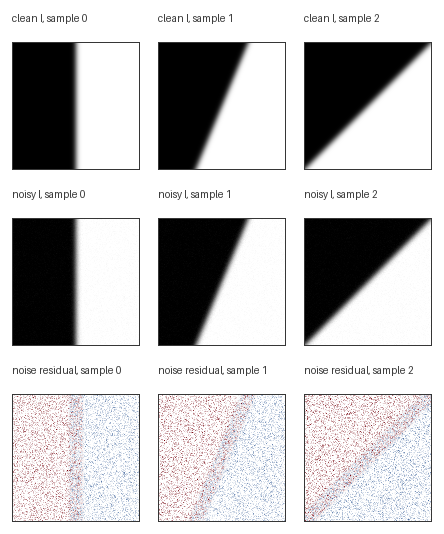

| setting | value |
| --- | --- |
| noise model | add_gaussian |
| sigma | 0.01 |
| seed | 7 |
| clamp | (0.0, 1.0) |

| tensor | shape | dtype | device | min | max | mean | std |
| --- | --- | --- | --- | --- | --- | --- | --- |
| noisy intensity | (3, 128, 128) | float32 | cpu | 0.000000 | 1.000000 | 0.499987 | 0.483520 |
| noise residual | (3, 128, 128) | float32 | cpu | -0.036891 | 0.039815 | -0.000013 | 0.007487 |

In [4]:
noisy = add_gaussian(frame.I, sigma=NOISE_SIGMA, seed=7, clamp=(0.0, 1.0))
residual = noisy - frame.I
assert noisy.shape == frame.I.shape

panels = []
for i in range(frame.I.shape[0]):
    panels.append({"title": f"clean I, sample {i}", "image": color_image(frame.I[i], vmin=0, vmax=1, palette="gray")})
for i in range(noisy.shape[0]):
    panels.append({"title": f"noisy I, sample {i}", "image": color_image(noisy[i], vmin=0, vmax=1, palette="gray")})
for i in range(residual.shape[0]):
    panels.append({"title": f"noise residual, sample {i}", "image": color_image(residual[i], palette="signed")})

display_image_grid("Stage 2. Noise applied, then noise settings and tensor table", panels)
markdown_table(
    [
        {"setting": "noise model", "value": "add_gaussian"},
        {"setting": "sigma", "value": NOISE_SIGMA},
        {"setting": "seed", "value": 7},
        {"setting": "clamp", "value": "(0.0, 1.0)"},
    ]
)
markdown_table([tensor_summary("noisy intensity", noisy), tensor_summary("noise residual", residual)])

**Stage 3. Filter output image, then filter/tensor table**

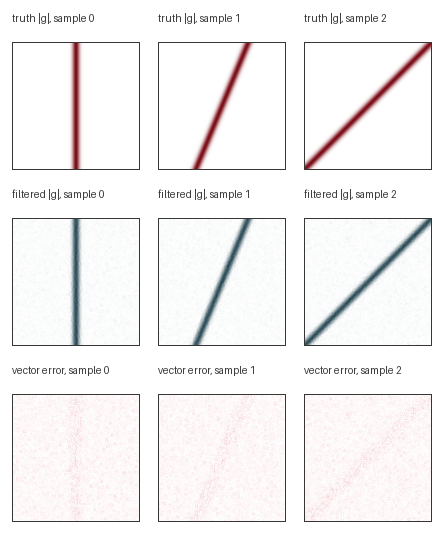

| setting | value |
| --- | --- |
| filter | sobel_3 |
| execution path | separable |
| boundary | replicate |

| tensor | shape | dtype | device | min | max | mean | std |
| --- | --- | --- | --- | --- | --- | --- | --- |
| filtered gx | (3, 128, 128) | float32 | cpu | -0.012147 | 0.164536 | 0.007681 | 0.026376 |
| filtered gy | (3, 128, 128) | float32 | cpu | -0.015893 | 0.121261 | 0.003573 | 0.015378 |
| filtered magnitude | (3, 128, 128) | float32 | cpu | 0.000000 | 0.168468 | 0.011674 | 0.029456 |
| vector error | (3, 128, 128) | float32 | cpu | 0.000000 | 0.082859 | 0.003442 | 0.002389 |

In [5]:
filter_definition = get_filter_definition("sobel_3")
gradient_x, gradient_y = run_filter(
    filter_definition,
    noisy,
    path=ExecutionPath.SEPARABLE,
    boundary=filter_definition.default_boundary,
)
filter_magnitude = torch.sqrt(gradient_x.square() + gradient_y.square())
vector_error = torch.sqrt((gradient_x - frame.gx).square() + (gradient_y - frame.gy).square())
filter_mag_max = max(float(filter_magnitude.detach().cpu().max()), truth_mag_max)
error_max = float(vector_error.detach().cpu().max())

panels = []
for i in range(frame.I.shape[0]):
    panels.append({"title": f"truth |g|, sample {i}", "image": color_image(truth_magnitude[i], vmin=0, vmax=filter_mag_max)})
for i in range(filter_magnitude.shape[0]):
    panels.append({"title": f"filtered |g|, sample {i}", "image": color_image(filter_magnitude[i], vmin=0, vmax=filter_mag_max, high=BRAND["congaree"])})
for i in range(vector_error.shape[0]):
    panels.append({"title": f"vector error, sample {i}", "image": color_image(vector_error[i], vmin=0, vmax=error_max, high=BRAND["rose"])})

display_image_grid("Stage 3. Filter output image, then filter/tensor table", panels)
markdown_table(
    [
        {"setting": "filter", "value": filter_definition.name},
        {"setting": "execution path", "value": ExecutionPath.SEPARABLE.value},
        {"setting": "boundary", "value": filter_definition.default_boundary.mode.value},
    ]
)
markdown_table(
    [
        tensor_summary("filtered gx", gradient_x),
        tensor_summary("filtered gy", gradient_y),
        tensor_summary("filtered magnitude", filter_magnitude),
        tensor_summary("vector error", vector_error),
    ]
)

**Stage 4. Metric masks, then score tables**

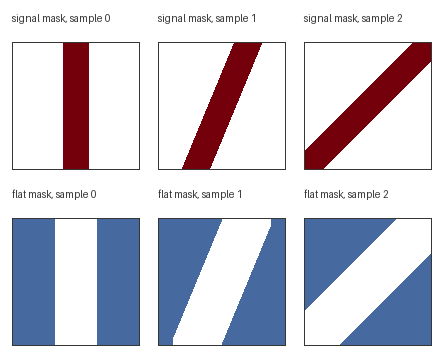

| sample | signal pixels | flat pixels |
| --- | --- | --- |
| 0 | 3328 | 11008 |
| 1 | 3642 | 9868 |
| 2 | 4394 | 8742 |

| sample | angle_rad | nrmse | angular_mae | magnitude_bias | noise_gain | tail_spurious_grad |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | 0.000000 | 0.137581 | 44.516590 | 0.032368 | 0.184676 | 0.008365 |
| 1 | 0.392699 | 0.142892 | 44.438156 | 0.030636 | 0.187005 | 0.008262 |
| 2 | 0.785398 | 0.153521 | 42.086185 | 0.026397 | 0.188266 | 0.008589 |

In [6]:
mask_dict = masks(frame.gx, frame.gy)

panels = []
for i in range(frame.I.shape[0]):
    panels.append(
        {
            "title": f"signal mask, sample {i}",
            "image": color_image(mask_dict["signal"][i].float(), vmin=0, vmax=1),
        }
    )
for i in range(frame.I.shape[0]):
    panels.append(
        {
            "title": f"flat mask, sample {i}",
            "image": color_image(mask_dict["flat"][i].float(), vmin=0, vmax=1, high=BRAND["atlantic"]),
        }
    )

display_image_grid("Stage 4. Metric masks, then score tables", panels)

mask_rows = []
for i in range(frame.I.shape[0]):
    mask_rows.append(
        {
            "sample": i,
            "signal pixels": int(mask_dict["signal"][i].sum().detach().cpu()),
            "flat pixels": int(mask_dict["flat"][i].sum().detach().cpu()),
        }
    )

scores = evaluate_metrics(
    gradient_x,
    gradient_y,
    frame.gx,
    frame.gy,
    metrics=("nrmse", "angular_mae", "magnitude_bias", "noise_gain", "tail_spurious_grad"),
    signal_mask=mask_dict["signal"],
    flat_mask=mask_dict["flat"],
    sigma_n=NOISE_SIGMA,
)
score_tensor = torch.stack([value for value in scores.values()])
assert torch.isfinite(score_tensor).all()
score_table = []
for i, angle in enumerate(angles.detach().cpu().tolist()):
    row = {"sample": i, "angle_rad": f"{float(angle):.6f}"}
    for name, values in scores.items():
        row[name] = f"{float(values.detach().cpu()[i]):.6f}"
    score_table.append(row)

markdown_table(mask_rows)
markdown_table(score_table)

In [7]:
component_flow = [
    {
        "stage": "1",
        "component": "agfb-generators",
        "call": "smoothed_step",
        "output": f"{tuple(frame.I.shape)} intensity batch and {tuple(frame.g.shape)} truth gradients",
    },
    {"stage": "2", "component": "agfb-noise", "call": "add_gaussian", "output": f"{tuple(noisy.shape)} noisy image batch"},
    {"stage": "3", "component": "agfb-filters", "call": "run_filter", "output": f"{tuple(gradient_x.shape)} gx and gy filtered gradients"},
    {"stage": "4", "component": "agfb-metrics", "call": "evaluate_metrics", "output": f"{len(scores)} metric tensors with one value per sample"},
]
markdown_table(component_flow)

| stage | component | call | output |
| --- | --- | --- | --- |
| 1 | agfb-generators | smoothed_step | (3, 128, 128) intensity batch and (3, 2, 128, 128) truth gradients |
| 2 | agfb-noise | add_gaussian | (3, 128, 128) noisy image batch |
| 3 | agfb-filters | run_filter | (3, 128, 128) gx and gy filtered gradients |
| 4 | agfb-metrics | evaluate_metrics | 5 metric tensors with one value per sample |